In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from datetime import datetime
from tensorflow.keras.models import Sequential

Exploring Data

In [ ]:
df= pd.read_csv('/content/drive/MyDrive/MicrosoftStock.csv')
df.head()

,index,date,open,high,low,close,volume,Name
0,390198,2013-02-08,27.35,27.71,27.31,27.55,33318306,MSFT
1,390199,2013-02-11,27.65,27.92,27.50,27.86,32247549,MSFT
2,390200,2013-02-12,27.88,28.00,27.75,27.88,35990829,MSFT
3,390201,2013-02-13,27.93,28.11,27.88,28.03,41715530,MSFT
4,390202,2013-02-14,27.92,28.06,27.87,28.04,32663174,MSFT


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   1259 non-null   int64  
 1   date    1259 non-null   object 
 2   open    1259 non-null   float64
 3   high    1259 non-null   float64
 4   low     1259 non-null   float64
 5   close   1259 non-null   float64
 6   volume  1259 non-null   int64  
 7   Name    1259 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 78.8+ KB


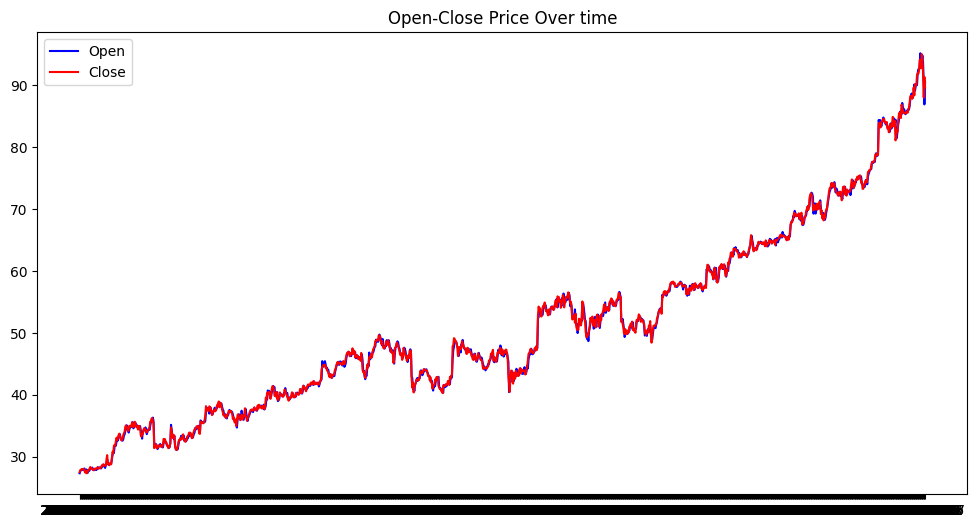

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df["date"],df['open'],label="Open",color="blue")
plt.plot(df["date"],df['close'],label="Close",color="red")
plt.title("Open-Close Price Over time")
plt.legend()
plt.show()

Trading Volume to check for Outliers

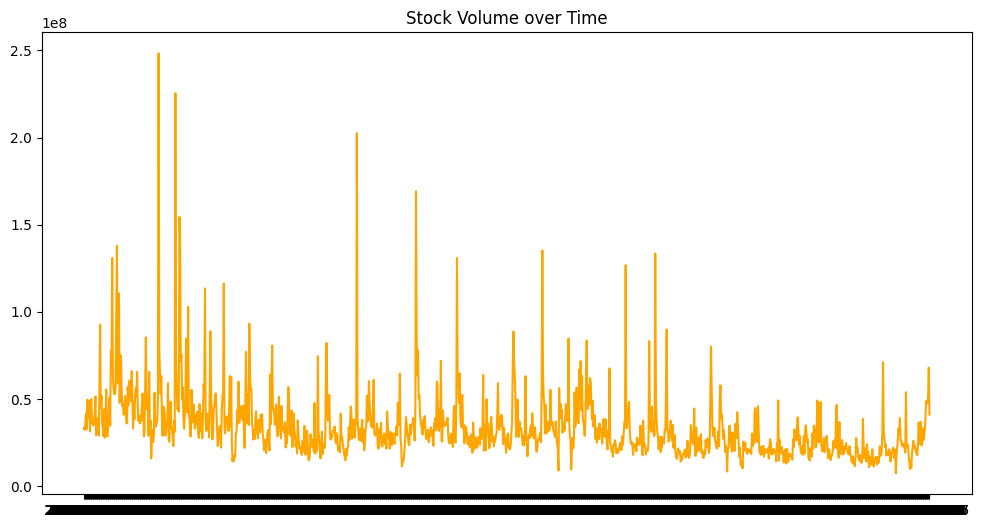

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df["date"],df['volume'],label='Volume',color='orange')
plt.title("Stock Volume over Time")
plt.show()

Drop non-numeric columns

In [ ]:
numeric_data=df.select_dtypes(include=["int64","float64"])

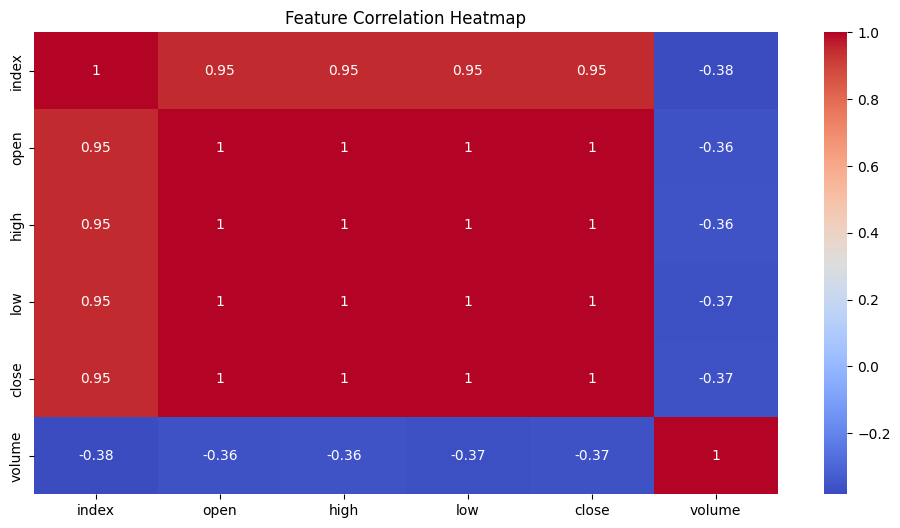

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(numeric_data.corr(),annot=True,cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
#Convert the date into datetime
df["date"]=pd.to_datetime(df["date"])

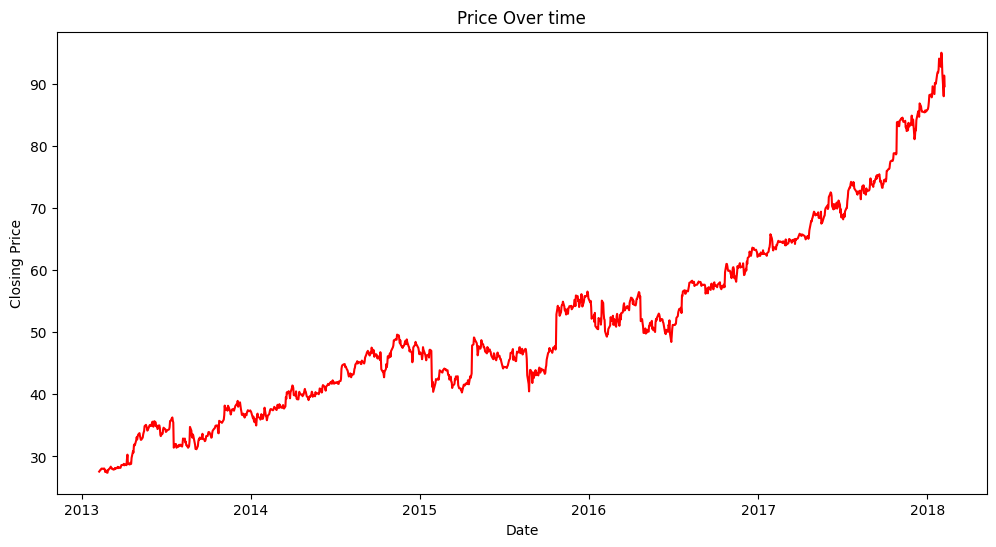

In [ ]:
#Closing Plot
plt.figure(figsize=(12,6))
plt.plot(df["date"],df['close'],color="red")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("Price Over time")
plt.show()

Prepare Data for LSTM Model

In [ ]:
stock_close=df['close']
dataset=stock_close.values.reshape(-1,1)
training_data_len=int(np.ceil(len(dataset)*0.85)) #dataset split
test_data = dataset[training_data_len:]
scaler=StandardScaler()
scaled_data=scaler.fit_transform(dataset)
training_data=scaled_data[:training_data_len]
test_data_scaled=scaler.transform(test_data)

Preprocessing Stages

In [ ]:
#Creating Sliding Window for stock (60 days)

x_train, y_train=[],[]
for i in range(60,len(training_data)):
  x_train.append(training_data[i-60:i,0])
  y_train.append(training_data[i,0])
x_train=np.array(x_train)
y_train=np.array(y_train)
x_train= np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))

print("X Train Shape:",x_train.shape)
print("Y Train Shape:", y_train.shape)

X Train Shape: (1011, 60, 1)
Y Train Shape: (1011,)


LSTM Model

In [ ]:
model=keras.models.Sequential()
model.add(keras.layers.LSTM(64,return_sequences=True,input_shape=(x_train.shape[1],1)))
model.add(keras.layers.LSTM(64,return_sequences=False))
model.add(keras.layers.Dense(128,activation="relu"))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(1))

model.summary()
model.compile(optimizer="adam",loss="mae",metrics=["accuracy",keras.metrics.RootMeanSquaredError()])
history=model.fit(x_train,y_train,epochs=20,batch_size=32)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 0.1988 - root_mean_squared_error: 0.2809
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.1169 - root_mean_squared_error: 0.1546
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.1121 - root_mean_squared_error: 0.1461
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0977 - root_mean_squared_error: 0.1310
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0978 - root_mean_squared_error: 0.1269
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0971 - root_mean_squared_error: 0.1282
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0945 - root_mean_squared_error: 0.1257
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0942 - root_mean_squared_error: 0.1272
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0904 - root_mean_squared_error: 0.1205
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0901 - root_mean_squared_error: 0.1186

In [ ]:
# Combine last 60 training values with test data
test_input = np.concatenate(
    (training_data[-60:], test_data_scaled),
    axis=0
)

x_test = []
y_test = []

for i in range(60, len(test_input)):

    # Previous 60 days
    x_test.append(test_input[i-60:i, 0])

    # Actual next day value
    y_test.append(test_input[i, 0])


x_test = np.array(x_test)
y_test = np.array(y_test)

# Reshape for LSTM/RNN
x_test = x_test.reshape(
    x_test.shape[0],
    x_test.shape[1],
    1
)

print(x_test.shape)
print(y_test.shape)

(188, 60, 1)
(188,)


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 270ms/step


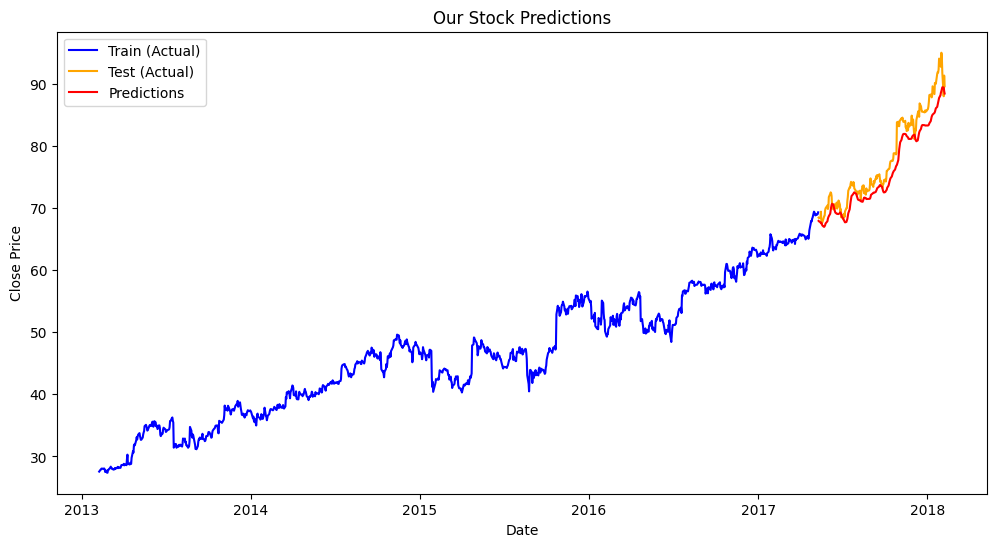

In [ ]:
predictions=model.predict(x_test)
predictions=scaler.inverse_transform(predictions)

train= df[:training_data_len]
test=df[training_data_len:]

test=test.copy()

test['predictions']= predictions

plt.figure(figsize=(12,6))
plt.plot(train['date'],train['close'],label="Train (Actual)",color="blue")
plt.plot(test['date'],test['close'],label="Test (Actual)",color="orange")
plt.plot(test['date'],test['predictions'],label="Predictions",color="red")
plt.title("Our Stock Predictions")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()


